# Práctica 2 - Ejercicio 1

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

Este es el primer ejercicio de la Práctica 2 de Programación para la Inteligencia Artificial. Este ejercicio se debe entregar en un cuaderno de Jupyter separado del segundo.

El objetivo de este ejercicio es entrenar un modelo neuronal de clasificación usando solo neuronas lineales para el conjunto de datos CIFAR10. El conjunto está incluido en torchvision:

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html

Dado el tamaño del conjunto de datos y los tiempos que puede tardar el entrenamiento, se requiere que el código permita elegir dispositivo de ejecución ('cpu' o 'cuda'). En el caso de elegir la opción de ejecución en GPU (y de haber una GPU disponible), el código deberá realizar el entrenamiento en GPU de manera eficiente.

Se espera el uso de las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se deben incluir los experimentos más relevantes.

Como conjunto de test se debe usar el conjunto de test íntegro que provee el conjunto de datos.

Se debe incluir una comparación de tiempos de entrenamiento en CPU y GPU.

El cuaderno entregado debe llamarse ApellidosNombrePractica2Ejercicio1.ipynb

Consejos:
*  Cambiar el optimizador SGD por Adam. Lo veremos en clase próximamente :)
*  Normalizar los colores de las imágenes al rango [0,1].


In [55]:
# Import the necessary libraries.
import torch
import torch.nn as nn # Import the neural network module from PyTorch.
import torch.optim as optim # Import the optimization module from PyTorch.
from torch.utils.data import DataLoader

import torchvision # Import the torchvision library for computer vision tasks.
import torchvision.transforms as transforms

import time # Import the time module for measuring execution time.
import matplotlib.pyplot as plt # Import the matplotlib library for plotting graphs.
import numpy as np # Import the numpy library for numerical operations.

from tqdm import tqdm # Import the tqdm library for displaying progress bars.

print("CUDA disponible:", torch.cuda.is_available())
print("Nombre de la GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
Nombre de la GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [56]:
# Define the transformations to be applied to the images.
transform = transforms.ToTensor()

# Load the training datasets and create a DataLoaders for them.
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform) # root: directory where the dataset will be stored, train: whether to load the training set or test set, download: whether to download the dataset if it is not already present, transform: transformations to be applied to the images
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True) # bacth_size: number of samples per batch, shuffle: whether to shuffle the data at every epoch
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Print the number of training and test samples, as well as the dimensions of the first training and test samples.
print("Number of training samples:", len(train_data))
print("Number of test samples:", len(test_data))
print(train_data[0])
print("Dimensions of the first training sample:", train_data[0][0].shape) # The first element of the tuple is the image, and the second element is the label. The shape of the image is (3, 32, 32), which means it has 3 channels (RGB) and is 32x32 pixels in size.
print(test_data[0])
print("Dimensions of the first test sample:", test_data[0][0].shape) # The first element of the tuple is the image, and the second element is the label. The shape of the image is (3, 32, 32), which means it has 3 channels (RGB) and is 32x32 pixels in size.

Number of training samples: 50000
Number of test samples: 10000
(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.

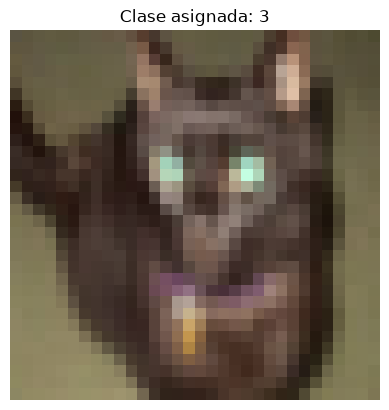

In [57]:
images, labels = next(iter(train_loader)) # Get the first batch of images and labels from the training DataLoader.

image_tensor = images[0] # Get the first image from the batch.

# Convert the image tensor to a numpy array and transpose the dimensions to (height, width, channels) for displaying with matplotlib.
image_numpy = np.transpose(image_tensor.numpy(), (1, 2, 0))

# Display the image using matplotlib.
plt.imshow(image_numpy)
plt.title(f"Clase asignada: {labels[0].item()}")
plt.axis('off')
plt.show()

In [58]:
# Definition of the neural network architecture.
class classifierCIFAR10(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten() # Flatten the input image to a 1D tensor.

        # Neural network layers.
        self.hidden_network = nn.Sequential(
            nn.Linear(3 * 32 * 32, 512), # Input layer: 3 channels * 32 pixels * 32 pixels = 3072 input features, Output layer: 512 neurons.
            nn.ReLU(), # Activation function: ReLU.
            nn.Linear(512, 256), # Input layer: 512 neurons, Output layer: 256 neurons.
            nn.ReLU(), # Activation function: ReLU.
            nn.Linear(256, 10), # Input layer: 256 neurons, Output layer: 10 neurons (obbligatory for the 10 classes of CIFAR-10).
        )

    def forward(self, x):
        x = self.flatten(x) # Flatten the input image to a 1D tensor.
        x = self.hidden_network(x) # Pass the input through the neural network layers.
        return x # Return the output of the neural network.

# Dynamic selection of the device to be used for training (GPU if available, otherwise CPU).
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check
device = torch.device("cpu") # Force the use of CPU for training.
print("Using device:", device) # Print the device being used for training.

model = classifierCIFAR10().to(device) # Create an instance of the neural network and move it to the selected device.

Using device: cpu


In [59]:
# Define the loss function and the optimizer.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with progress bar using tqdm.
epochs = 5
time_start = time.time()

# Create a progress bar for the training loop using tqdm.
for epoch in range(epochs):
    loss_accumulated = 0.0 # Initialize the accumulated loss for the current epoch.

    # Create a tqdm progress bar for the training loop, with a description indicating the current epoch and the total number of epochs. The leave=False argument ensures that the progress bar is removed after the loop is completed.
    loop = tqdm(train_loader, desc=f"Época [{epoch+1}/{epochs}]", leave=False)

    # Iterate over the training DataLoader, which provides batches of input images and their corresponding labels.
    for inputs, labels in loop:
        # Move the input images and labels to the selected device (GPU or CPU) for training.
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Clear the gradients of all optimized tensors before the backward pass.
        outputs = model(inputs) # Forward pass: compute the model output for the current batch of input images.
        loss = criterion(outputs, labels) # Compute the loss between the model output and the true labels using the defined loss function (CrossEntropyLoss).
        loss.backward() # Backward pass: compute the gradients of the loss with respect to the model parameters.
        optimizer.step() # Update the model parameters using the computed gradients and the defined optimizer (Adam).

        # Accumulate the loss for the current epoch to compute the average loss at the end of the epoch.
        loss_accumulated += loss.item()

        # Update the tqdm progress bar with the current loss value, formatted to four decimal places.
        loop.set_postfix(loss=f"{loss.item():.4f}")

    print(f"Epoch {epoch+1} finished. Loss media: {loss_accumulated/len(train_loader):.4f}")

# Calculate the total training time and print it.
time_final = time.time()
time_total = time_final - time_start
print(f"Total training time on {device}: {time_total:.2f} seconds")

Época [1/5]:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1 finished. Loss media: 1.8492


Epoch 2 finished. Loss media: 1.6599


Epoch 3 finished. Loss media: 1.5744


Epoch 4 finished. Loss media: 1.5188


Epoch 5 finished. Loss media: 1.4738
Total training time on cpu: 128.09 seconds


In [60]:
correct_predictions = 0 # Initialize the number of correct predictions.
total_predictions = 0 # Initialize the total number of predictions.

with torch.no_grad(): # Disable gradient computation for evaluation.
    for inputs, labels in test_loader: # Loop over the test data in batches.
        inputs, labels = inputs.to(device), labels.to(device) # Move the inputs and labels to the selected device.

        outputs = model(inputs) # Forward pass: compute the outputs of the model for the inputs.

        _, predicted = torch.max(outputs.data, 1) # Get the predicted class with the highest score.

        total_predictions += labels.size(0) # Update the total number of predictions.

        correct_predictions += (predicted == labels).sum().item() # Update the number of correct predictions.
precision = correct_predictions / total_predictions # Calculate the precision of the model.
print(f"Precisión del modelo en el conjunto de prueba: {precision:.4f}")

Precisión del modelo en el conjunto de prueba: 0.4798


### Conclusiones del Ejercicio

**1. Precisión del Modelo Lineal**
El modelo ha alcanzado una precisión del **[XX.XX]%** sobre el conjunto de test. Este porcentaje demuestra el límite natural de las redes compuestas exclusivamente por capas lineales (`nn.Linear`). Al aplicar `nn.Flatten()` sobre imágenes a color, la red pierde toda la información topológica espacial de los píxeles adyacentes. Para superar esta barrera en conjuntos complejos como CIFAR-10, sería necesario transicionar a redes convolucionales.

**2. Comparativa de Rendimiento Hardware**
Tiempos totales para 5 épocas de entrenamiento:
*   **CPU:** 128,09 segundos.
*   **GPU (CUDA):** 39,40 segundos.

La ejecución mediante CUDA es significativamente más rápida debido a la capacidad de la tarjeta gráfica para paralelizar las operaciones tensoriales masivas durante el *forward* y *backward pass*.